In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.preprocessing import StandardScaler

In [2]:
power_df = pd.read_csv("../dataset/NTUST.csv", index_col=0, parse_dates=True)
power_df = power_df.asfreq('h')  # pastikan frekuensi hourly
power_df = power_df.loc[power_df.index.year != 2020, ["KW"]].round(2).copy()


In [3]:
power_df.head()

,KW
timestamp,
2019-01-23 00:00:00,359.32
2019-01-23 01:00:00,308.63
2019-01-23 02:00:00,284.17
2019-01-23 03:00:00,252.00
2019-01-23 04:00:00,263.33


In [4]:
power_df.tail()

,KW
timestamp,
2019-12-31 19:00:00,416.52
2019-12-31 20:00:00,413.42
2019-12-31 21:00:00,399.26
2019-12-31 22:00:00,387.49
2019-12-31 23:00:00,353.23


In [5]:
weather_df = pd.read_csv("../dataset/NSRDB.csv")
weather_df.index = power_df.index 

In [6]:
weather_df.head()

,YEAR,MONTH,DAY,HOUR,TEMPERATURE,DEW_POINT,GHI,PRESSURE,WIND_SPEED,RELATIVE HUMIDITY,PRECIPITABLE WATER,CLOUD_TYPE
timestamp,,,,,,,,,,,,
2019-01-23 00:00:00,2019,1,23,0,14.3,8.8,0,1032,4.1,69.69,1.4,0
2019-01-23 01:00:00,2019,1,23,1,14.2,8.8,0,1031,4.1,70.21,1.4,3
2019-01-23 02:00:00,2019,1,23,2,14.1,8.9,0,1031,4.1,71.05,1.4,3
2019-01-23 03:00:00,2019,1,23,3,14.1,9.0,0,1031,4.1,71.62,1.4,0
2019-01-23 04:00:00,2019,1,23,4,14.1,9.2,0,1031,4.0,72.27,1.4,3


In [7]:
weather_df.tail()

,YEAR,MONTH,DAY,HOUR,TEMPERATURE,DEW_POINT,GHI,PRESSURE,WIND_SPEED,RELATIVE HUMIDITY,PRECIPITABLE WATER,CLOUD_TYPE
timestamp,,,,,,,,,,,,
2019-12-31 19:00:00,2019,12,31,19,16.3,12.7,0,1039,6.6,79.46,2.6,3
2019-12-31 20:00:00,2019,12,31,20,16.3,12.8,0,1039,6.5,79.67,2.6,3
2019-12-31 21:00:00,2019,12,31,21,16.3,12.9,0,1039,6.3,80.06,2.5,3
2019-12-31 22:00:00,2019,12,31,22,16.3,13.0,0,1039,6.1,80.74,2.4,3
2019-12-31 23:00:00,2019,12,31,23,16.3,13.1,0,1038,6.0,81.17,2.4,3


In [8]:
weather_df = weather_df.drop(columns=['YEAR', 'MONTH', 'DAY', 'HOUR'])

In [9]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8232 entries, 2019-01-23 00:00:00 to 2019-12-31 23:00:00
Freq: h
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TEMPERATURE         8232 non-null   float64
 1   DEW_POINT           8232 non-null   float64
 2   GHI                 8232 non-null   int64  
 3   PRESSURE            8232 non-null   int64  
 4   WIND_SPEED          8232 non-null   float64
 5   RELATIVE HUMIDITY   8232 non-null   float64
 6   PRECIPITABLE WATER  8232 non-null   float64
 7   CLOUD_TYPE          8232 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 578.8 KB


In [10]:
print(weather_df.shape)
print(power_df.shape)

(8232, 8)
(8232, 1)


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_50663/4146627371.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = power_df.resample('M').mean()


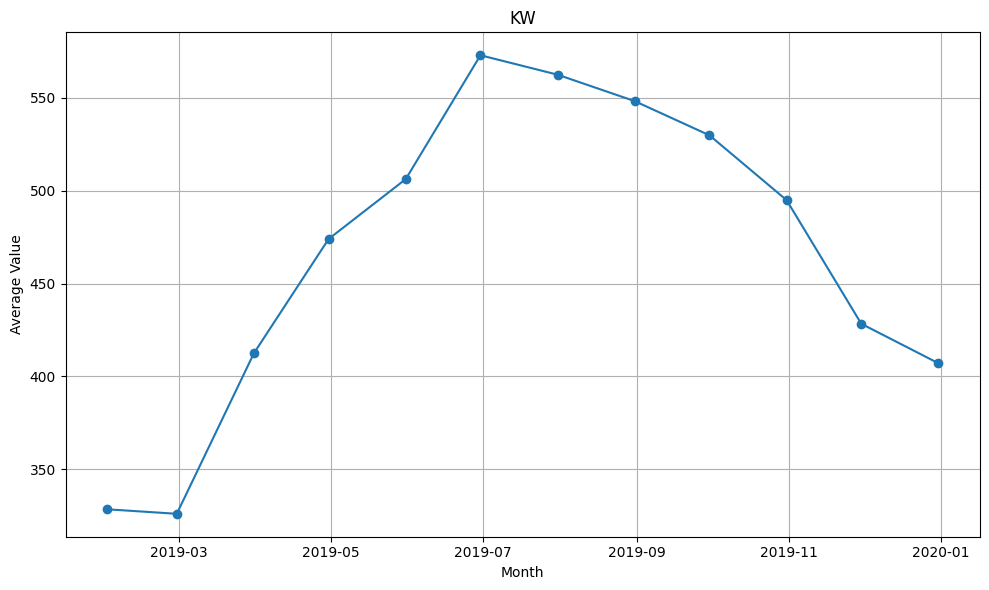

In [11]:
power_df.index = pd.to_datetime(power_df.index)

# Resample data menjadi rata-rata bulanan
monthly_data = power_df.resample('M').mean()

# Setup plot tunggal
plt.figure(figsize=(10, 6))
plt.plot(monthly_data.index, monthly_data["KW"], marker='o', linestyle='-')
plt.title("KW")
plt.xlabel("Month")
plt.ylabel("Average Value")
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/97/8bx4_dmx3038pm1qrblmtrl80000gn/T/ipykernel_50663/1207388737.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = weather_df.resample('M').mean()


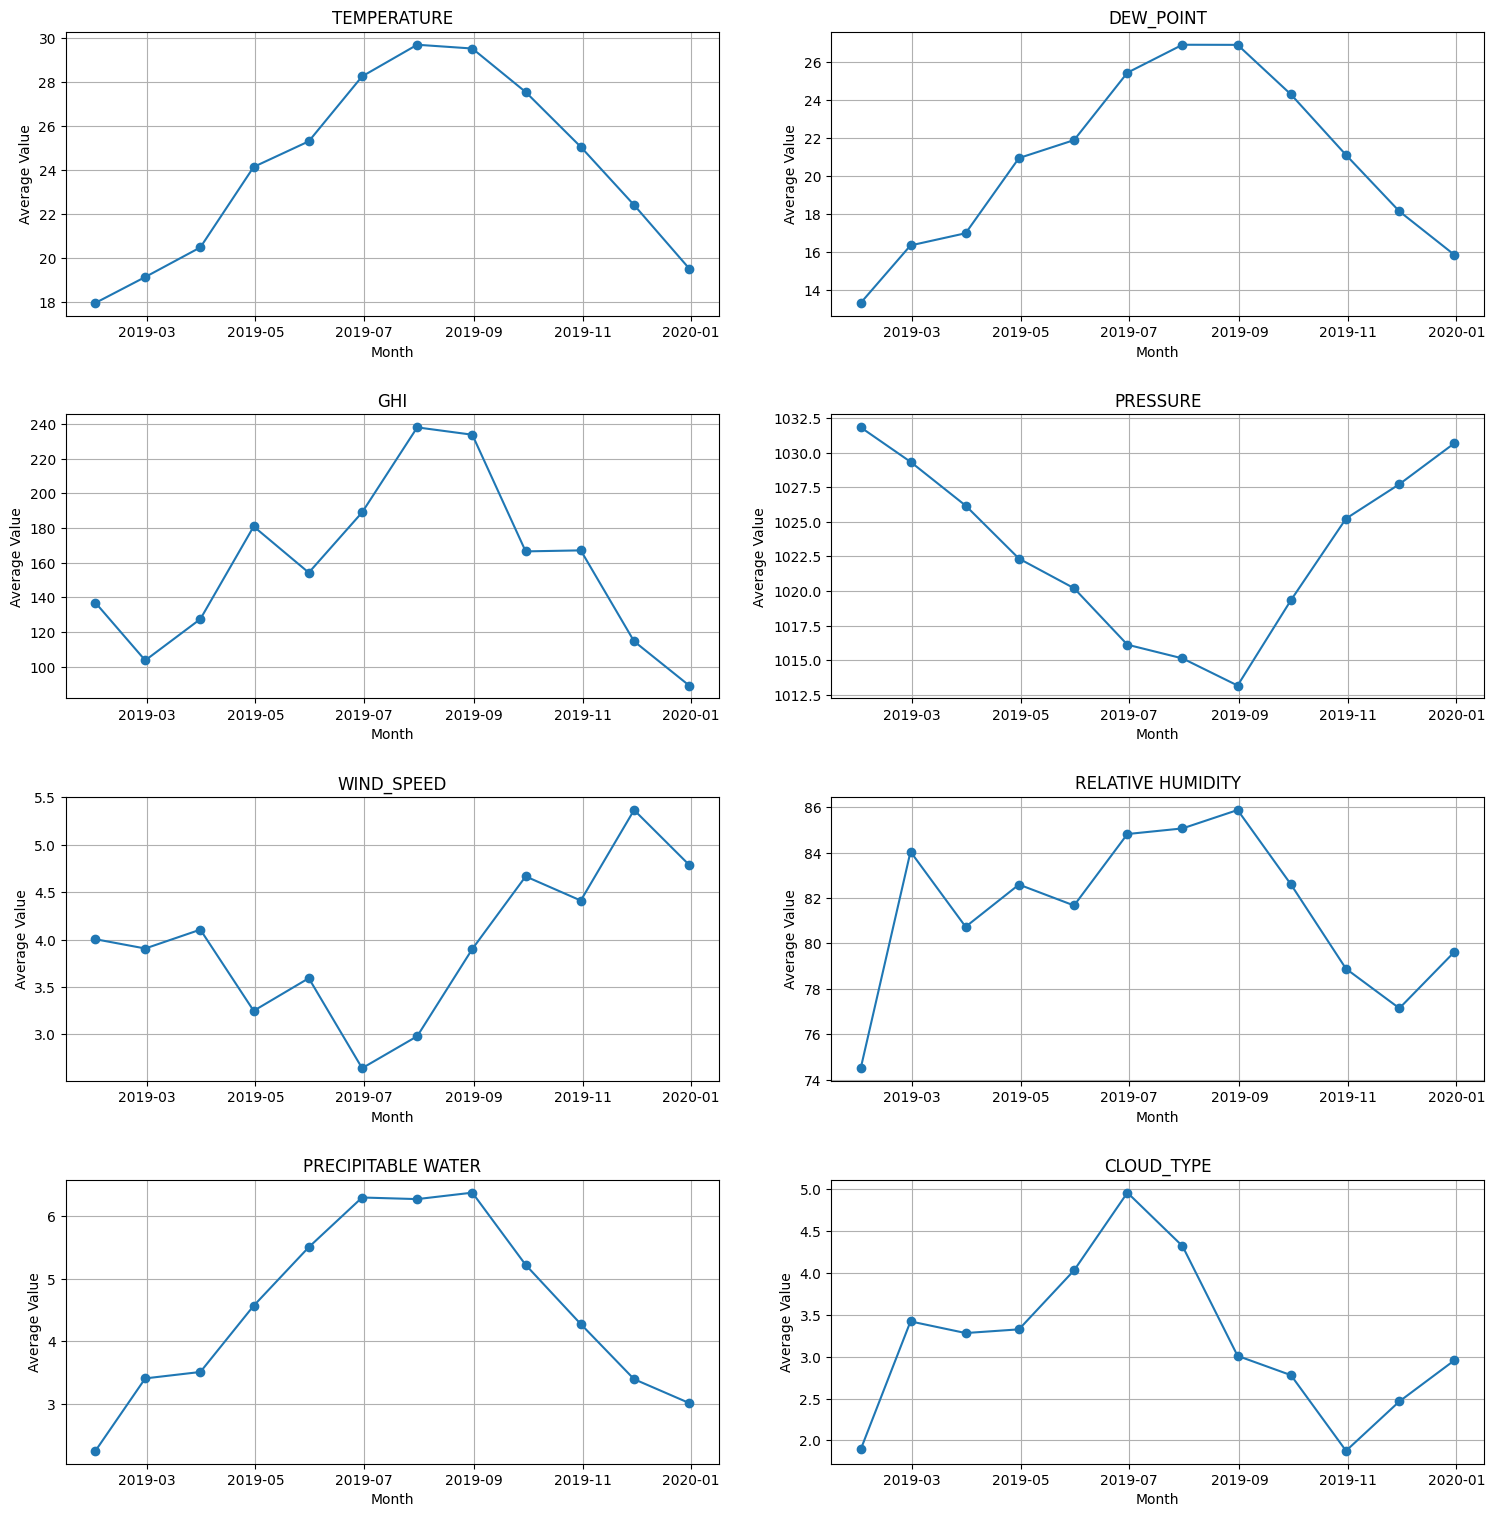

In [12]:
# Pastikan index sudah dalam format datetime
weather_df.index = pd.to_datetime(weather_df.index)

# Resampling data per bulan dengan rata-rata
monthly_data = weather_df.resample('M').mean()

# Setup plot
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
fig.tight_layout(pad=5.0)

# Kolom-kolom yang akan diplot
columns = [
    'TEMPERATURE',
    'DEW_POINT',
    'GHI',
    'PRESSURE',
    'WIND_SPEED',
    'RELATIVE HUMIDITY',
    'PRECIPITABLE WATER',
    'CLOUD_TYPE'
]

axes = axes.flatten()

# Plot tiap kolom
for i, column in enumerate(columns):
    ax = axes[i]
    ax.plot(monthly_data.index, monthly_data[column], marker='o', linestyle='-')
    ax.set_title(column)
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Value')
    ax.grid(True)

# Tampilkan plot
plt.show()


In [13]:
# Gabungkan secara kolom (axis=1) berdasarkan index datetime
combined_df = pd.concat([power_df["KW"], weather_df], axis=1)

# Cek data hasil gabungan
print(combined_df.head())


                         KW  TEMPERATURE  DEW_POINT  GHI  PRESSURE  \
timestamp                                                            
2019-01-23 00:00:00  359.32         14.3        8.8    0      1032   
2019-01-23 01:00:00  308.63         14.2        8.8    0      1031   
2019-01-23 02:00:00  284.17         14.1        8.9    0      1031   
2019-01-23 03:00:00  252.00         14.1        9.0    0      1031   
2019-01-23 04:00:00  263.33         14.1        9.2    0      1031   

                     WIND_SPEED  RELATIVE HUMIDITY  PRECIPITABLE WATER  \
timestamp                                                                
2019-01-23 00:00:00         4.1              69.69                 1.4   
2019-01-23 01:00:00         4.1              70.21                 1.4   
2019-01-23 02:00:00         4.1              71.05                 1.4   
2019-01-23 03:00:00         4.1              71.62                 1.4   
2019-01-23 04:00:00         4.0              72.27               

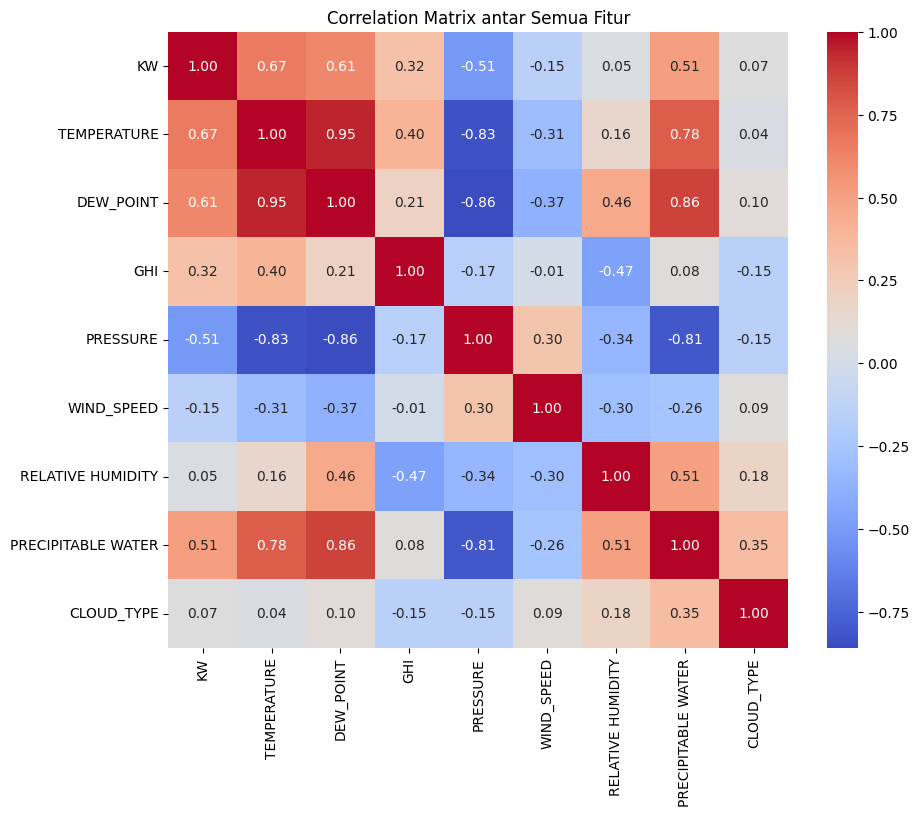

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung korelasi
corr_matrix = combined_df.corr()

# Visualisasikan dengan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix antar Semua Fitur")
plt.show()


In [15]:
print(combined_df.corr()["KW"].sort_values(ascending=False))


KW                    1.000000
TEMPERATURE           0.666033
DEW_POINT             0.613370
PRECIPITABLE WATER    0.506498
GHI                   0.320896
CLOUD_TYPE            0.074982
RELATIVE HUMIDITY     0.046703
WIND_SPEED           -0.149321
PRESSURE             -0.512292
Name: KW, dtype: float64


In [16]:
print(combined_df.corr()["TEMPERATURE"].sort_values(ascending=False))


TEMPERATURE           1.000000
DEW_POINT             0.947692
PRECIPITABLE WATER    0.780527
KW                    0.666033
GHI                   0.403617
RELATIVE HUMIDITY     0.156180
CLOUD_TYPE            0.041042
WIND_SPEED           -0.311811
PRESSURE             -0.832715
Name: TEMPERATURE, dtype: float64


In [17]:
print(combined_df.corr()["GHI"].sort_values(ascending=False))


GHI                   1.000000
TEMPERATURE           0.403617
KW                    0.320896
DEW_POINT             0.208560
PRECIPITABLE WATER    0.083732
WIND_SPEED           -0.008674
CLOUD_TYPE           -0.154457
PRESSURE             -0.166859
RELATIVE HUMIDITY    -0.471357
Name: GHI, dtype: float64


In [18]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'ADF Test untuk {name}')
    print(f'  Test Statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print(f'  Critical Values: {result[4]}')
    if result[1] < 0.05:
        print("  => Stasioner ✅\n")
    else:
        print("  => Tidak Stasioner ❌\n")

# Lakukan ADF test ke semua kolom
for column in combined_df.columns:
    adf_test(combined_df[column], column)


ADF Test untuk KW
  Test Statistic : -6.3167
  p-value        : 0.0000
  Critical Values: {'1%': -3.431148114843182, '5%': -2.8618927107356664, '10%': -2.5669577431342314}
  => Stasioner ✅

ADF Test untuk TEMPERATURE
  Test Statistic : -3.0244
  p-value        : 0.0327
  Critical Values: {'1%': -3.4311483097089566, '5%': -2.8618927968410914, '10%': -2.566957788968979}
  => Stasioner ✅

ADF Test untuk DEW_POINT
  Test Statistic : -3.3939
  p-value        : 0.0112
  Critical Values: {'1%': -3.4311483097089566, '5%': -2.8618927968410914, '10%': -2.566957788968979}
  => Stasioner ✅

ADF Test untuk GHI
  Test Statistic : -9.4497
  p-value        : 0.0000
  Critical Values: {'1%': -3.4311483097089566, '5%': -2.8618927968410914, '10%': -2.566957788968979}
  => Stasioner ✅

ADF Test untuk PRESSURE
  Test Statistic : -3.6699
  p-value        : 0.0046
  Critical Values: {'1%': -3.431147822722828, '5%': -2.8618925816563077, '10%': -2.5669576744240463}
  => Stasioner ✅

ADF Test untuk WIND_SPEED
 